# Sphere Simulation

In [1]:
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from geomstats.geometry.hypersphere import Hypersphere
import geomstats.visualization as visualization

In [2]:
plt.rcParams.update({'font.size': 10,
                     'mathtext.fontset': 'stix',
                     'font.family': 'serif',
                     'font.serif':'Palatino'})

## Setting up

In [3]:
sphere = Hypersphere(dim=2)

np.random.seed(123)

mean1 = np.array([0., 0., 1.])
mean2 = -mean1
tau2 = 0.1


B_large = 100
B_small = 10

In [4]:
def sample_G(n_samples): 
    classes = np.random.randint(0,2,n_samples).reshape(-1,1)
    samples1 = sphere.random_riemannian_normal(mean1, 1./tau2, n_samples)
    samples2 = sphere.random_riemannian_normal(mean2, 1./tau2, n_samples)
    return classes*samples1 + (1-classes)*samples2

In [5]:
def denoiser(X, M, rho):
    
    poly = sp.special.legendre(0)
    poly_deriv = poly.deriv()
    for m in range(1,M):
        poly += (2*m+1)*sp.special.legendre(m)
        poly_deriv += (2*m+1)*sp.special.legendre(m).deriv()

    hat_f = np.zeros(shape=X.shape[0])
    hat_grad_f = np.zeros(shape=(X.shape[0],3))
    
    for i in range(X.shape[0]):  
        dot = X @ X[i,:]
        hat_f += poly(dot)
        hat_grad_f += np.outer(poly_deriv(dot), X[i,:])
        
    hat_f /= (4*np.pi*X.shape[0])
    hat_grad_f /= (4*np.pi*X.shape[0])

    hat_score = hat_grad_f / np.maximum(hat_f, rho).reshape(-1,1)
    
    delta = np.zeros((X.shape[0],3))
    for i in range(X.shape[0]):
        x_ = X[i,:].reshape(-1,1)
        v = X[i,:] + sigma2*(np.eye(3) - x_@ x_.T)@hat_score[i,:]
        delta[i,:] = sphere.metric.exp(v, X[i,:])
    
    return delta

## Fixed $\sigma^2$, varying $n$

In [6]:
sigma2 = 0.1
ns = np.logspace(2,4,num=21)

In [7]:
# compute naive risk

Theta = sample_G(B_large)
X = sphere.random_riemannian_normal(Theta, 1./sigma2, B_large)
N_risk_1 = sphere.metric.squared_dist(X,Theta)

In [8]:
# compute empirical tangent Bayes risks

M = 6
rho = 1e-2

T_risk_1 = np.zeros((len(ns),B_small))

N = int(ns[-1])
for b in range(B_small):
    print(b)
    
    Theta_all = sample_G(N)
    X_all = sphere.random_riemannian_normal(Theta_all, 1./sigma2, N)
    for j in range(len(ns)):
        n = int(ns[j])

        Theta = Theta_all[:n,:]
        X = X_all[:n,:]
        delta = denoiser(X, M, rho)

        T_risk_1[j,b] = np.mean(sphere.metric.squared_dist(delta,Theta))

0
1
2
3
4
5
6
7
8
9


In [9]:
N_risk_1_mean = np.mean(N_risk_1)
N_risk_1_std = np.std(N_risk_1)

T_risk_1_mean = np.mean(T_risk_1, axis=1)
T_risk_1_std = np.std(T_risk_1, axis=1)

In [11]:

T_risk_1_mean

array([0.1717099 , 0.15943017, 0.16748369, 0.15997988, 0.15997639,
       0.14924127, 0.1477762 , 0.13945191, 0.13398576, 0.12660393,
       0.12345261, 0.12116584, 0.11834356, 0.11532083, 0.11371102,
       0.11315325, 0.11233904, 0.11179965, 0.11109159, 0.11074701,
       0.11045851])

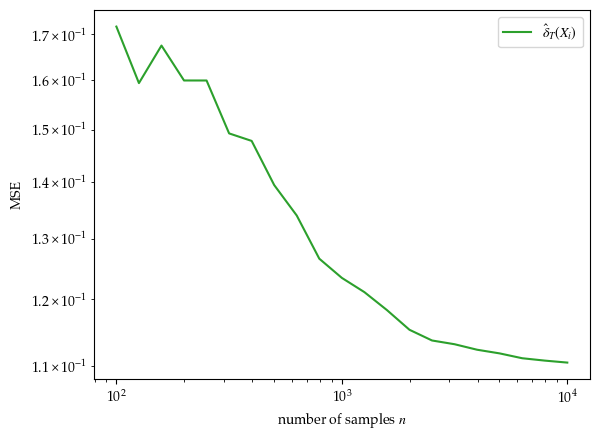

In [12]:
# plt.loglog(ns, N_risk_1_mean*np.ones_like(ns), color='C0', label='$X_i$')
# plt.fill_between(ns, N_risk_1_mean-N_risk_1_std/B_large,
#                  N_risk_1_mean+N_risk_1_std/B_large, color='C0', alpha=0.2)

plt.loglog(ns, T_risk_1_mean, color='C2', label='$\\hat{\\delta}_T(X_i)$')
# plt.fill_between(ns, T_risk_1_mean-T_risk_1_std/B_small,
#                  T_risk_1_mean+T_risk_1_std/B_small, color='C2', alpha=0.2)

plt.xlabel('number of samples $n$')
plt.ylabel('MSE')

plt.legend()

## Fixed $n$, varying $\sigma^2$

In [80]:
sigma2s = np.linspace(1e-5,0.3,num=20)
n = 1000

In [81]:
# compute naive risk and empirical tangent Bayes risk

M = 3
rho = 1e-2

N_risk_2 = np.zeros((len(sigma2s),B_small))
T_risk_2 = np.zeros((len(sigma2s),B_small))

for j in range(len(sigma2s)):
    sigma2 = sigma2s[j]
    print(sigma2)
    
    for b in range(B_small):

        
        Theta = sample_G(n)
        X = sphere.random_riemannian_normal(Theta, 1./sigma2, n)
        N_risk_2[j,b] = np.mean(sphere.metric.squared_dist(X,Theta))
        
        delta = denoiser(X, M, rho) # need to pass sigma2 as argument?

        T_risk_2[j,b] = np.mean(sphere.metric.squared_dist(delta,Theta))

1e-05
0.01579894736842105
0.031587894736842106
0.047376842105263155
0.0631657894736842
0.07895473684210526
0.0947436842105263
0.11053263157894735
0.12632157894736842
0.14211052631578946
0.15789947368421053
0.17368842105263158
0.18947736842105262
0.20526631578947369
0.22105526315789473
0.2368442105263158
0.25263315789473684
0.2684221052631579
0.2842110526315789
0.3


In [82]:
N_risk_2_mean = np.mean(N_risk_2,axis=1)
N_risk_2_std = np.std(N_risk_2,axis=1)

T_risk_2_mean = np.mean(T_risk_2, axis=1)
T_risk_2_std = np.std(T_risk_2, axis=1)

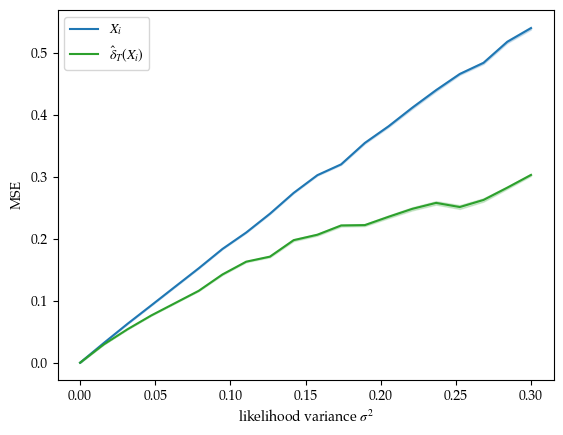

In [83]:
plt.plot(sigma2s, N_risk_2_mean, color='C0', label='$X_i$')
plt.fill_between(sigma2s, N_risk_2_mean-N_risk_2_std/B_small,
                 N_risk_2_mean+N_risk_2_std/B_small, color='C0', alpha=0.2)

plt.plot(sigma2s, T_risk_2_mean, color='C2', label='$\\hat{\\delta}_T(X_i)$')
plt.fill_between(sigma2s, T_risk_2_mean-T_risk_2_std/B_small,
                 T_risk_2_mean+T_risk_2_std/B_small, color='C2', alpha=0.2)

plt.xlabel('likelihood variance $\\sigma^2$')
plt.ylabel('MSE')

plt.legend()

## Plotting

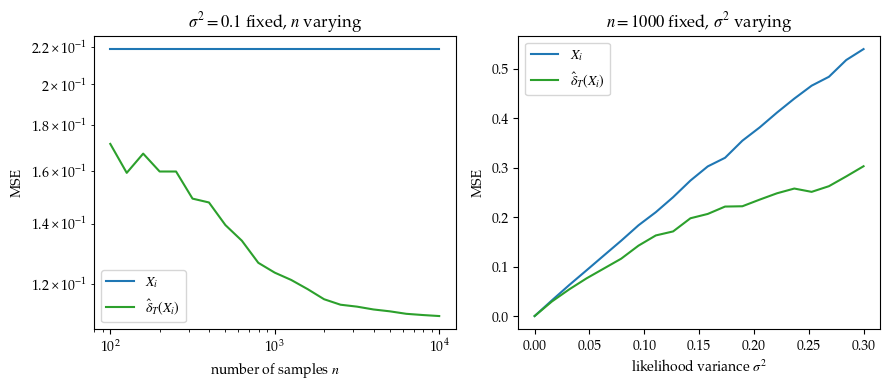

In [85]:
fig = plt.figure(figsize=(9,4))
ax = [None] * 2

ax[0] = fig.add_subplot(121)

ax[0].loglog(ns, N_risk_1_mean*np.ones_like(ns), color='C0', label='$X_i$')
# ax[0].fill_between(ns, N_risk_1_mean-N_risk_1_std/B_large,
#                  N_risk_1_mean+N_risk_1_std/B_large, color='C0', alpha=0.2)
ax[0].loglog(ns, T_risk_1_mean, color='C2', label='$\\hat{\\delta}_T(X_i)$')
# ax[0].fill_between(ns, T_risk_1_mean-T_risk_1_std/B_small,
#                  T_risk_1_mean+T_risk_1_std/B_small, color='C2', alpha=0.2)
ax[0].set_xlabel('number of samples $n$')
ax[0].set_ylabel('MSE')
ax[0].set_title('$\\sigma^2 = 0.1$ fixed, $n$ varying')
ax[0].legend()

ax[1] = fig.add_subplot(122)
ax[1].plot(sigma2s, N_risk_2_mean, color='C0', label='$X_i$')
# ax[1].fill_between(sigma2s, N_risk_2_mean-N_risk_2_std/B_small,
#                  N_risk_2_mean+N_risk_2_std/B_small, color='C0', alpha=0.2)
ax[1].plot(sigma2s, T_risk_2_mean, color='C2', label='$\\hat{\\delta}_T(X_i)$')
# ax[1].fill_between(sigma2s, T_risk_2_mean-T_risk_2_std/B_small,
#                  T_risk_2_mean+T_risk_2_std/B_small, color='C2', alpha=0.2)
ax[1].set_xlabel('likelihood variance $\\sigma^2$')
ax[1].set_ylabel('MSE')
ax[1].set_title('$n=1000$ fixed, $\\sigma^2$ varying')
ax[1].legend()

plt.tight_layout()

plt.savefig('simulation.pdf')